# Multi-Target Activity Prediction and a Selectivity-Profiling App

*Predicting a compound's activity across nine protein targets from ChEMBL, comparing a per-target ensemble to a unified model, and deploying the result as an interactive Streamlit application.*

## Abstract

Single-target QSAR predicts activity against one protein; drug discovery also needs the selectivity profile across many targets. Bioactivity data for nine targets (hERG, BACE1, EGFR, CDK2, JAK2, PARP1, BRD4, Aurora A, PIK3CA) were curated from ChEMBL (~58000 molecule-target records after filtering IC50 measurements and deduplicating). Two multi-target strategies were compared: an ensemble of per-target XGBoost models (Approach A) and a single unified XGBoost trained on all pairs with a one-hot target encoding (Approach B). Approach A outperformed Approach B on all nine targets (mean held-out R2 about 0.63 versus 0.46), because a one-hot flag is too weak a mechanism to let one tree model serve targets with different structure-activity relationships. A qualitative validation on known drugs behaved sensibly (gefitinib ranked EGFR highest, aspirin scored low throughout), while revealing a calibration bias in the Aurora A model. The per-target ensemble was deployed as a Streamlit application that returns an activity profile with a hERG cardiotoxicity flag and an applicability-domain warning. A multi-task graph neural network is identified as the principled route to genuine cross-target transfer and left as future work.

## 1. Introduction

The earlier notebook modelled activity against a single protein at a time. In practice, a drug candidate must be understood through its selectivity profile: the pattern of activity across many targets, which governs both efficacy and off-target toxicity (polypharmacology). This notebook predicts activity across nine therapeutically relevant targets simultaneously and turns the result into a usable tool.

Data are drawn from ChEMBL, filtered to IC50 measurements with an exact relation and biochemical assay type, converted to pIC50 and deduplicated per molecule by median, exactly as in the single-target notebook. An important lesson emerged during data assembly: target ChEMBL identifiers must be verified, not trusted. Several identifiers initially used resolved, on inspection, to the wrong protein (for example an identifier labelled BACE1 pointed to a Pim kinase), which would have trained mislabelled models silently. Confirming each identifier against its ChEMBL preferred name corrected the panel before any modelling.

Two multi-target strategies are compared. Approach A trains one model per target and queries them together, giving a ranked activity profile. Approach B trains a single model on all molecule-target pairs, encoding the target identity as a one-hot vector, so that a shared structure-activity mapping can, in principle, borrow strength across targets. The two are compared on held-out data, sanity-checked against known drugs, and the better one is deployed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 80     # reduit la taille affichee de TOUTES les figures
plt.rcParams["font.size"] = 9       # texte compact mais lisible
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 8

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RepeatedKFold, KFold, cross_validate, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from collections import defaultdict
from xgboost import XGBRegressor

print("Libraries imported.")

Libraries imported.


## 2. Data

For each target, IC50 activities were retrieved from ChEMBL, curated (nanomolar units, values between 1 and 1e7 nM, valid SMILES), converted to pIC50 and reduced to one median value per molecule. Targets with more than 200 curated molecules were retained, giving nine targets and roughly 58000 molecule-target records in total.

| Target | ChEMBL role | n (curated) |
|---|---|---|
| hERG | potassium channel (safety) | 8348 |
| BACE1 | beta-secretase 1 | 8135 |
| EGFR | growth factor receptor kinase | 10128 |
| CDK2 | cyclin-dependent kinase | 2099 |
| JAK2 | tyrosine kinase | 9274 |
| PARP1 | DNA-repair enzyme | 3395 |
| BRD4 | bromodomain protein | 7948 |
| Aurora A | mitotic kinase | 2488 |
| PIK3CA | PI3-kinase | 6246 |

The panel spans channels, kinases, an enzyme and an epigenetic reader, providing a diverse test of the multi-target approach.

In [2]:
from chembl_webresource_client.new_client import new_client

targets = {
    "hERG": "CHEMBL240",          # KCNH2  (OK)
    "BACE1": "CHEMBL4822",        # a verifier
    "EGFR": "CHEMBL203",          # OK
    "CDK2": "CHEMBL301",          # OK
    "JAK2": "CHEMBL2971",         # a verifier
    "PARP1": "CHEMBL3105",        # a verifier
    "BRD4": "CHEMBL1163125",      # a verifier
    "Aurora A": "CHEMBL4722",     # AURKA, a verifier
    "PIK3CA": "CHEMBL4005",       # a verifier
    # KRAS G12C : incertain, voir ci-dessous
}

def get_target_data(chembl_id):
    res = new_client.activity.filter(
        target_chembl_id=chembl_id, standard_type="IC50",
        relation="=", assay_type="B",
    ).only(["molecule_chembl_id", "canonical_smiles", "standard_value", "standard_units"])
    df = pd.DataFrame(res)
    if len(df) == 0:
        return pd.DataFrame(columns=["smiles", "pIC50"])
    df = df[df["standard_units"] == "nM"]
    df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")
    df = df.dropna(subset=["standard_value", "canonical_smiles"])
    df = df[(df["standard_value"] >= 1) & (df["standard_value"] <= 1e7)]
    df["pIC50"] = 9 - np.log10(df["standard_value"])
    df = (df.groupby("molecule_chembl_id")
            .agg(smiles=("canonical_smiles", "first"), pIC50=("pIC50", "median"))
            .reset_index(drop=True))
    return df

In [4]:
data = {}
for name, cid in targets.items():
    df_t = get_target_data(cid)
    print(name, "| molecules:", len(df_t))
    if len(df_t) > 200:
        data[name] = df_t
print("kept targets:", list(data.keys()))

hERG | molecules: 8348
BACE1 | molecules: 8135
EGFR | molecules: 10128
CDK2 | molecules: 2099
JAK2 | molecules: 9274
PARP1 | molecules: 3395
BRD4 | molecules: 7948
Aurora A | molecules: 2488
PIK3CA | molecules: 6246
kept targets: ['hERG', 'BACE1', 'EGFR', 'CDK2', 'JAK2', 'PARP1', 'BRD4', 'Aurora A', 'PIK3CA']


## 3. Methods

Molecular features are identical to the single-target notebook: a 2048-bit ECFP4 fingerprint plus seven physicochemical descriptors. Approach A trains one XGBoost regressor per target (default hyperparameters), each evaluated on an 80/20 hold-out. Approach B stacks all targets into one dataset, appends a nine-dimensional one-hot encoding of the target to each molecule's features, and trains a single XGBoost; it is evaluated per target on a stratified hold-out so that each target is represented in the test set. Because the two approaches use different splits, their comparison is indicative rather than strictly matched. Model quality is reported with both RMSE (absolute error, in pIC50 units) and R2 (variance explained), the latter being the fairer metric for comparing targets whose activity ranges differ. Finally, the models are sanity-checked qualitatively by predicting the profiles of known drugs and asking whether their primary target ranks highly.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        'LogP': Descriptors.MolLogP(mol),
        'MolWt': Descriptors.MolWt(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol),
        'NumRotatableBonds': Descriptors.NumRotatableBonds(mol)
    }

def compute_fingerprint(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits)
    return np.array(fp)

def build_feature_matrix(smiles_series):
    desc_list = smiles_series.apply(compute_descriptors).tolist()
    valid_mask = [d is not None for d in desc_list]
    smiles_valid = smiles_series[valid_mask].reset_index(drop=True)
    descriptors = pd.DataFrame([d for d in desc_list if d is not None])
    fp_matrix = np.array([compute_fingerprint(s) for s in smiles_valid])
    X = np.hstack([fp_matrix, descriptors.values])
    return X, smiles_valid, descriptors

def build_Xy(smiles_series, target_series):
    X, smiles_valid, desc = build_feature_matrix(smiles_series)
    valid_mask = smiles_series.apply(lambda s: Chem.MolFromSmiles(s) is not None).values
    y = target_series[valid_mask].reset_index(drop=True)
    return X, y, smiles_valid, desc

models_A = {}     # un modele par cible
results_A = {}

for name, df_t in data.items():
    X, y, _sm, _d = build_Xy(df_t["smiles"], df_t["pIC50"])
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    m = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)
    rmse = mean_squared_error(yte, pred) ** 0.5
    r2 = r2_score(yte, pred)
    models_A[name] = m
    results_A[name] = (rmse, r2)
    print(name.ljust(10), "| n:", len(y), "| RMSE:", round(rmse, 3), "| R2:", round(r2, 3))

hERG       | n: 8348 | RMSE: 0.624 | R2: 0.528
BACE1      | n: 8135 | RMSE: 0.718 | R2: 0.654
EGFR       | n: 10128 | RMSE: 0.769 | R2: 0.625
CDK2       | n: 2099 | RMSE: 0.767 | R2: 0.653
JAK2       | n: 9274 | RMSE: 0.648 | R2: 0.659
PARP1      | n: 3395 | RMSE: 0.605 | R2: 0.722
BRD4       | n: 7948 | RMSE: 0.575 | R2: 0.758
Aurora A   | n: 2488 | RMSE: 0.73 | R2: 0.553
PIK3CA     | n: 6246 | RMSE: 0.649 | R2: 0.664


## 4. Results

### 4.1 Approach A: per-target ensemble

Trained independently, the nine models reach held-out R2 between 0.53 and 0.76 (RMSE 0.58 to 0.77 pIC50 units). The best-modelled targets are BRD4 (R2 = 0.76), PARP1 (0.72) and PIK3CA (0.66), which have rich, coherent chemical series; the hardest are hERG (0.53) and Aurora A (0.55). Note that RMSE alone would be misleading here: hERG has a low RMSE (0.62) yet the lowest R2, simply because its activity distribution is narrow, so a small absolute error still explains little variance. R2 is therefore the better cross-target comparator.

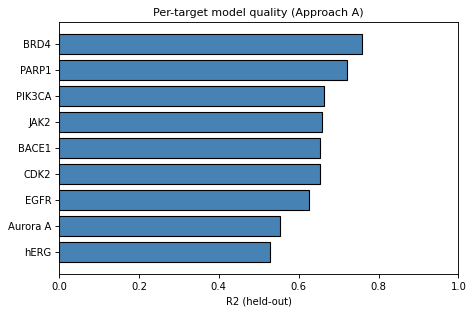

In [6]:
import matplotlib.pyplot as plt

names = list(results_A.keys())
r2s = [results_A[n][1] for n in names]
order = np.argsort(r2s)                     # tri croissant
names = [names[i] for i in order]
r2s = [r2s[i] for i in order]

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(names, r2s, color="steelblue", edgecolor="black")
ax.set_xlabel("R2 (held-out)")
ax.set_title("Per-target model quality (Approach A)")
ax.set_xlim(0, 1)
plt.tight_layout(); plt.show()

In [7]:
X_list, y_list, t_list = [], [], []
target_names = list(data.keys())

for ti, name in enumerate(target_names):
    X, y, _sm, _d = build_Xy(data[name]["smiles"], data[name]["pIC50"])
    onehot = np.zeros((len(y), len(target_names)), dtype=np.float32)
    onehot[:, ti] = 1                        # one-hot de la cible
    X_list.append(np.hstack([X, onehot]).astype(np.float32))
    y_list.append(np.asarray(y))
    t_list.append(np.full(len(y), ti))

X_all = np.vstack(X_list)
y_all = np.concatenate(y_list)
t_all = np.concatenate(t_list)
print("unified X:", X_all.shape)             # attendu ~ (58000, 2064)

unified X: (58061, 2064)


### 4.2 Approach B: unified model, and comparison

The unified one-hot model underperforms the per-target ensemble on every one of the nine targets, often substantially.

| Target | A (per-target) R2 | B (unified) R2 |
|---|---|---|
| hERG | 0.528 | 0.392 |
| BACE1 | 0.654 | 0.513 |
| EGFR | 0.625 | 0.489 |
| CDK2 | 0.653 | 0.380 |
| JAK2 | 0.659 | 0.516 |
| PARP1 | 0.722 | 0.498 |
| BRD4 | 0.758 | 0.633 |
| Aurora A | 0.553 | 0.316 |
| PIK3CA | 0.664 | 0.445 |

The result refutes the intuition that sharing data across targets should help, especially the small ones. A one-hot flag lets a tree make a few target-specific splits, but forces a single shared structure-activity mapping across proteins whose SARs are genuinely different: the same substructure does not mean the same thing for a kinase and for an ion channel. The model settles on a compromise that fits no target as well as its dedicated counterpart. Multi-target sharing is not free; it requires either closely related targets or a mechanism that learns a shared representation with target-specific outputs, which a one-hot XGBoost is not.

In [8]:
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte, ttr, tte = train_test_split(
    X_all, y_all, t_all, test_size=0.2, random_state=42, stratify=t_all)

unified = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
unified.fit(Xtr, ytr)
pred = unified.predict(Xte)

print("Target      |  A R2  |  B R2")
for ti, name in enumerate(target_names):
    mask = tte == ti
    r2_B = r2_score(yte[mask], pred[mask])
    r2_A = results_A[name][1]
    print(name.ljust(10), "|", round(r2_A, 3), " |", round(r2_B, 3))

Target      |  A R2  |  B R2
hERG       | 0.528  | 0.392
BACE1      | 0.654  | 0.513
EGFR       | 0.625  | 0.489
CDK2       | 0.653  | 0.38
JAK2       | 0.659  | 0.516
PARP1      | 0.722  | 0.498
BRD4       | 0.758  | 0.633
Aurora A   | 0.553  | 0.316
PIK3CA     | 0.664  | 0.445


In [10]:
def featurize_one(smiles):
    fp = compute_fingerprint(smiles)
    desc = compute_descriptors(smiles)
    if fp is None or desc is None:
        return None
    return np.hstack([fp, list(desc.values())]).reshape(1, -1).astype(np.float32)

def predict_profile(smiles):
    x = featurize_one(smiles)
    if x is None:
        return None
    profile = {name: float(m.predict(x)[0]) for name, m in models_A.items()}
    return dict(sorted(profile.items(), key=lambda kv: kv[1], reverse=True))

### 4.3 Validation on known drugs

As a qualitative check, the per-target models were used to predict activity profiles for known drugs. Gefitinib, an EGFR inhibitor, correctly ranked EGFR as its top predicted target, confirming that the method recovers a known primary target when that target is in the panel. Imatinib, whose true targets (BCR-ABL, KIT, PDGFR) are absent from the panel, ranked a kinase highest but not its real target, illustrating that the model can only rank what it has been trained on. Aspirin, a non-kinase drug, produced uniformly low predictions, a reassuring negative control. The exercise also exposed a limitation: Aurora A ranked near the top for every molecule, including aspirin, indicating that its model is optimistically calibrated. Cross-target ranking is only meaningful when the per-target models are comparably calibrated, which the independent ensemble does not guarantee, and which a jointly trained model would address.

Gefitinib ( GEFITINIB ) -> top3: [('EGFR', 7.51), ('Aurora A', 7.22), ('PARP1', 6.84)]
Imatinib ( IMATINIB ) -> top3: [('Aurora A', 7.19), ('PARP1', 7.15), ('CDK2', 6.64)]
Aspirin ( ASPIRIN ) -> top3: [('Aurora A', 5.93), ('JAK2', 5.19), ('PARP1', 5.09)]


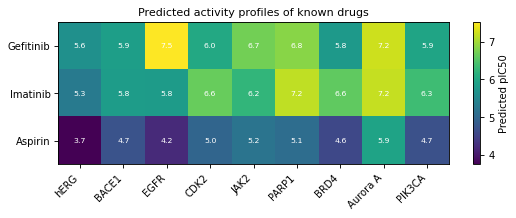

In [13]:
drug_ids = {"Gefitinib": "CHEMBL939", "Imatinib": "CHEMBL941", "Aspirin": "CHEMBL25"}
for drug, cid in drug_ids.items():
    rec = new_client.molecule.get(cid)
    smi = rec["molecule_structures"]["canonical_smiles"]
    prof = predict_profile(smi)
    top3 = list(prof.items())[:3]
    print(drug, "(", rec["pref_name"], ") -> top3:", [(t, round(v, 2)) for t, v in top3])

drug_ids = {"Gefitinib": "CHEMBL939", "Imatinib": "CHEMBL941", "Aspirin": "CHEMBL25"}
target_order = list(models_A.keys())

matrix, drug_labels = [], []
for drug, cid in drug_ids.items():
    smi = new_client.molecule.get(cid)["molecule_structures"]["canonical_smiles"]
    prof = predict_profile(smi)
    matrix.append([prof[t] for t in target_order])   # remis dans l'ordre fixe des cibles
    drug_labels.append(drug)
matrix = np.array(matrix)

fig, ax = plt.subplots(figsize=(7, 2.8))
im = ax.imshow(matrix, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(target_order))); ax.set_xticklabels(target_order, rotation=45, ha="right")
ax.set_yticks(range(len(drug_labels))); ax.set_yticklabels(drug_labels)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, round(matrix[i, j], 1), ha="center", va="center", color="white", fontsize=7)
fig.colorbar(im, label="Predicted pIC50")
ax.set_title("Predicted activity profiles of known drugs")
plt.tight_layout(); plt.show()

### 4.4 Deployment: interactive application

The per-target ensemble is deployed as a Streamlit application with two tabs, extending the earlier solubility predictor. Given a SMILES string, the "Target Activity" tab returns the predicted pIC50 against all nine targets as a colour-coded profile (likely active, moderate, inactive), with hERG shown separately as a cardiotoxicity flag (high predicted hERG activity is a safety risk, the opposite of an efficacy target). A Tanimoto-based applicability-domain warning flags molecules dissimilar to the training set, and a disclaimer states that predictions are for research use only, not clinical advice.

In [14]:
import joblib, os
os.makedirs("models", exist_ok=True)

joblib.dump(models_A, "models/target_models.joblib")

all_train_smiles = []
for name, df_t in data.items():
    all_train_smiles += df_t["smiles"].tolist()
joblib.dump(sorted(set(all_train_smiles)), "models/train_smiles.joblib")

print("saved", len(models_A), "models and", len(set(all_train_smiles)), "reference SMILES")

saved 9 models and 56870 reference SMILES


In [15]:
import joblib, os
os.makedirs("../models", exist_ok=True)
joblib.dump(models_A, "../models/target_models.joblib")

all_train_smiles = []
for name, df_t in data.items():
    all_train_smiles += df_t["smiles"].tolist()
joblib.dump(sorted(set(all_train_smiles)), "../models/train_smiles.joblib")
print("saved to:", os.path.abspath("../models"))

saved to: c:\Users\coure\Projects\cheminformatics\models


## 5. Discussion

The comparison delivers a clear, if unglamorous, message: for this data and these features, a simple ensemble of per-target models outperforms a unified model with one-hot target encoding on every target. Naive parameter sharing dilutes rather than transfers, because the targets' structure-activity relationships are too heterogeneous to be captured by a single tree mapping with a categorical flag. This does not condemn multi-task learning; it condemns the weakest form of it. The principled alternative, a multi-task graph neural network with a shared message-passing trunk and per-target output heads, learns a common molecular representation while allowing each target its own head, and jointly calibrates the outputs, which would also address the Aurora A calibration bias seen in validation. Building and training such a model was attempted but blocked by an environment issue and is left as a well-motivated extension.

Several limitations temper the conclusions. Comparisons between the two approaches used different train/test splits and are therefore indicative rather than exact. The activity profiles are only as reliable as the per-target calibration, which the independent ensemble does not enforce. Evaluation used random splits, so the numbers reflect in-distribution performance rather than generalisation to novel scaffolds, which single-target work showed to be markedly harder for bioactivity. And the whole approach is ligand-based: it predicts activity from molecular structure without any three-dimensional information about the binding site, so it complements, but does not replace, structure-based methods such as docking.

## 6. Conclusion

A nine-target activity predictor was assembled from curated ChEMBL data and deployed as an interactive selectivity-profiling application with a built-in cardiotoxicity flag. The main scientific finding is methodological: a per-target ensemble beats a unified one-hot model across all targets, showing that effective multi-target learning depends on the sharing mechanism, not merely on pooling data. Careful data curation, verifying target identifiers and consolidating noisy measurements, proved as decisive as the modelling itself. A multi-task graph neural network is the natural next step toward genuine cross-target transfer and joint calibration.

## References

[1] Subramanian, G. et al. Computational modeling of beta-secretase 1 (BACE-1) inhibitors using ligand-based approaches. J. Chem. Inf. Model. 56, 1936-1949 (2016).

[2] Yang, K. et al. Analyzing learned molecular representations for property prediction. J. Chem. Inf. Model. 59, 3370-3388 (2019). DOI: 10.1021/acs.jcim.9b00237

[3] Xiong, Z. et al. Pushing the boundaries of molecular representation for drug discovery with the graph attention mechanism. J. Med. Chem. 63, 8749-8760 (2020). DOI: 10.1021/acs.jmedchem.9b00959

[4] Sanguinetti, M.C. & Tristani-Firouzi, M. hERG potassium channels and cardiac arrhythmia. Nature 440, 463-469 (2006). DOI: 10.1038/nature04710

[5] Zdrazil, B. et al. The ChEMBL Database in 2023. Nucleic Acids Res. 52, D1180-D1192 (2024). DOI: 10.1093/nar/gkad1004